In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
import pandas as pd
import scipy.signal as sig
import scipy.ndimage as ndi
import stackview as st
import networkx as nx
import matplotlib.pyplot as plt
import skimage as ski
import iplotx as ipx

from copy import copy
from tifffile import imread

from pyfibre.fibers.metrics import fibre_network_metrics
from pyfibre.fibers.metrics import fibre_metrics
from pyfibre.fibers.network_extraction import fibre_network_assignment
from pyfibre.fibers.analysis import network_analysis
from pyfibre.fibers.fibre_network import FibreNetwork

In [2]:
example_dir = "/home/vpc/Pictures/Exemplo_Picro/"
example_output_dir = os.path.join(example_dir, 'Saída')

os.makedirs(example_output_dir, exist_ok=True)
stack_path = os.path.join(example_dir, 'stack.tif')
stack = imread(stack_path)
pol= stack[5]

# Pre-processing

In [4]:
from pyfibre.tools.filters import tubeness, hysteresis
from pyfibre.utilities import clear_border
from pyfibre.tools.preprocessing import clip_intensities, nl_means

In [6]:
pol_hsv = ski.color.rgb2hsv(pol)
pol_val = pol_hsv[..., 2]
pol_hue = pol_hsv[..., 0]
pol_sat = pol_hsv[..., 1]

In [8]:
SIGMA = 2
p1 = 50
p2 = 100

hue_inv = clip_intensities(
    ski.util.invert(
        ndi.gaussian_filter(pol_hue, sigma=SIGMA)
    ), p_intensity=(p1,p2)
)
hue_thresh = ski.filters.threshold_otsu(hue_inv)
hue_mask = ski.morphology.remove_small_objects(hue_inv > hue_thresh)

In [9]:
pol_val_corr = pol_val * hue_mask

pol_val_dn = nl_means(
    ski.exposure.equalize_adapthist(
        clip_intensities(
            pol_val_corr
        )
    )
)

In [10]:
st.blend(pol_val, pol_val_dn, zoom_factor=0.25)

In [ ]:
SIGMA=1
SCALE=0.5

pol_r = ski.transform.rescale(
    pol_val_dn,
    SCALE,
    mode='constant',
    anti_aliasing=None
)

SIGMA *= SCALE

pol_tb = tubeness(pol_r)

pol_thresh = ski.morphology.remove_small_objects(
    hysteresis(pol_tb, alpha=0.5), max_size=32
)

pol_edt = ndi.distance_transform_edt(
    pol_thresh
)

pol_distance = clear_border(
    ndi.gaussian_filter(
        pol_edt,
        sigma=1
    )
)

# Nucleation points

In [70]:
nuc_graph = nx.Graph()

pos = {}

for i in range(n_nuc):
    coords = np.array([
        nuc_x[i], nuc_y[i]
    ])
    pos[i] = coords
    nuc_graph.add_node(i, pos=coords, index=i)

nx.apply_matplotlib_colors(
    nuc_graph, "index", "color", plt.colormaps.get_cmap('prism')
)

In [71]:
nuc_graph.nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 

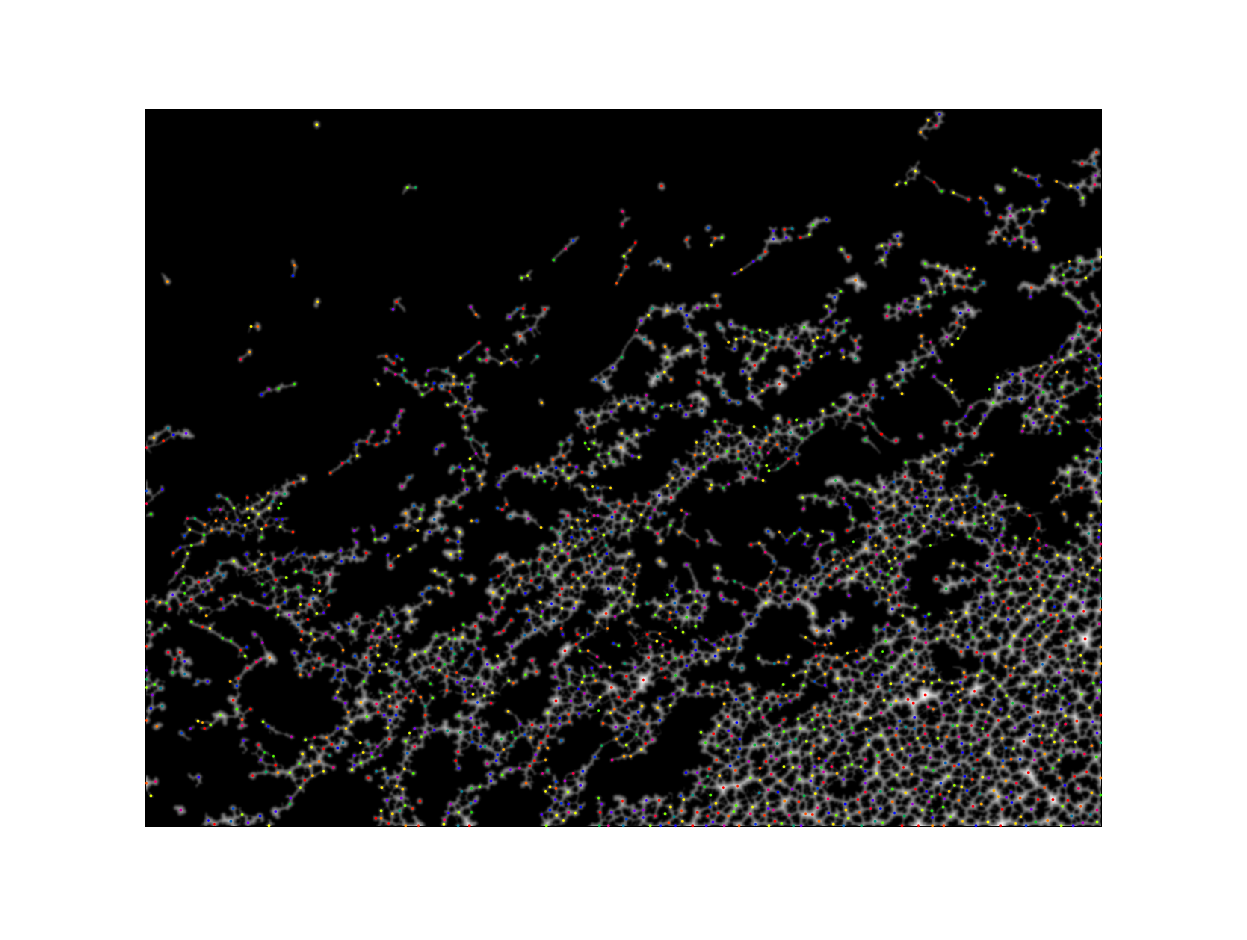

In [72]:
f, a = plt.subplots()
st.imshow(pol_distance, axes=a, continue_drawing=True)

style = {
    "vertex": {
        "facecolor": nuc_graph.nodes.data("color"),
        "size": 1
    }
}

ipx.network(
    nuc_graph,
    layout=pos,
    style=style,
    ax=a
)

f.set_dpi(200)
f.tight_layout()

In [247]:
NUC_RADIUS=10
NUC_THRESH = 5 # Because distance transform has weird values
R_THRESH = 11
FILT_RAD = R_THRESH // 2

In [ ]:
peak_coords = ski.feature.peak_local_max(
    pol_distance,
    labels=pol_thresh,
    threshold_abs=NUC_THRESH,
    min_distance=R_THRESH,
    footprint=np.ones((NUC_RADIUS, NUC_RADIUS)),
    exclude_border=10
)

nuc_y, nuc_x = peak_coords[:, 0], peak_coords[:, 1]

maxima = np.zeros_like(pol_distance)
maxima[nuc_y, nuc_x] = 1
n_nuc = len(peak_coords)

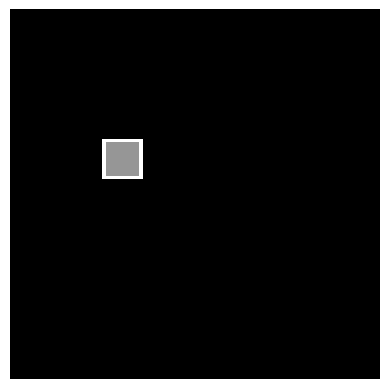

In [ ]:
# New ring filter !!!!
dummy_coords = np.array([30, 40])

dummy = np.zeros((100,100))

(y1, y2), (x1, x2) = np.array([
    dummy_coords - (FILT_RAD),
    dummy_coords + (FILT_RAD)])

dummy[x1:x2+1, y1:y2+1] = 1
dummy[x1+1:x2, y1+1:y2] = 0.5

st.imshow(dummy)

In [ ]:

for nuc in pos:
    nuc_coord = pos[nuc]

    ring_filter = ring(
        np.zeros(pol_distance.shape),
        nuc_coord,
        [R_THRESH // 2],
        1
    )